In [3]:
import pandas as pd

df = pd.read_excel('superstore_cleaned.xlsx')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Delivery Days,Order Month/Year
0,7980,CA-2015-103800,2015-01-03,2015-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095.0,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,4,Jan-2015
1,740,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,4,Jan-2015
2,741,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,4,Jan-2015
3,742,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,4,Jan-2015
4,1760,CA-2015-141817,2015-01-05,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,7,Jan-2015


# 1. Top 10 customers by revenue:

In [4]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


From the analysis, we can see the top 10 customers by total sales revenue. Sean Miller is the highest revenue-generating customer, followed by Tamara Chand and Raymond Buch. This list can be valuable for targeted marketing and customer retention strategies.

In [9]:
total_sales = df['Sales'].sum()
top_customers_sales = top_customers.sum()
percentage_contribution = (top_customers_sales / total_sales) * 100
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Top 10 Customers Sales: ${top_customers_sales:,.2f}")
print(f"Top 10 Customers Contribution: {percentage_contribution:.2f}%")

Total Sales: $2,261,255.41
Top 10 Customers Sales: $153,811.17
Top 10 Customers Contribution: 6.80%


Building on the previous analysis, the top 10 customers contribute approximately **6.80%** of the total sales revenue. This concentration of revenue among a small number of customers suggests a moderate dependency on these key accounts. While these customers are valuable assets, such a dependency can pose a business risk. Losing even one or two of these top customers could have a substantial impact on overall revenue. Therefore, it is critical to implement robust customer relationship management (CRM) strategies for these accounts, focusing on retention and satisfaction. Simultaneously, the company should explore strategies to diversify its customer base and reduce over-reliance on a few dominant clients, perhaps by identifying and nurturing potential high-value customers from the next tiers.

From the analysis, we can see the top 10 customers by total sales revenue. Sean Miller is the highest revenue-generating customer, followed by Tamara Chand and Raymond Buch. This list can be valuable for targeted marketing and customer retention strategies.

# 2. Month-over-month growth rate %:

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
growth_rate = monthly_sales.pct_change() * 100
print(growth_rate)

Order Date
2015-01            NaN
2015-02     -68.182562
2015-03    1121.396374
2015-04     -49.959090
2015-05     -14.411259
2015-06      45.163660
2015-07      -1.577349
2015-08     -19.726768
2015-09     200.999048
2015-10     -61.465286
2015-11     147.692389
2015-12     -12.502753
2016-01     -73.496058
2016-02     -33.849344
2016-03     170.589961
2016-04       5.612827
2016-05     -12.282252
2016-06     -21.229159
2016-07      21.224652
2016-08      28.698297
2016-09      71.473245
2016-10     -50.879192
2016-11     142.648125
2016-12      -0.937945
2017-01     -75.125308
2017-02      23.925178
2017-03     122.661869
2017-04     -24.401989
2017-05      46.476860
2017-06     -29.885891
2017-07      -3.533596
2017-08     -20.298601
2017-09     126.550118
2017-10     -13.889127
2017-11      32.699683
2017-12      21.086840
2018-01     -54.588601
2018-02     -54.179823
2018-03     195.484265
2018-04     -39.619692
2018-05      23.307898
2018-06       9.959265
2018-07      -6.983965


The month-over-month growth rate percentage shows significant fluctuations. We observe periods of high growth, such as March 2015 (1121.39%) and September 2015 (200.99%), often followed by sharp declines. This volatility could indicate seasonality, promotional effects, or market instability. Further analysis is needed to identify underlying patterns, but it suggests a need for more stable and predictable growth strategies.

# 3. Correlation between delivery days and order value:

In [6]:
df['Delivery Days'] = (pd.to_datetime(df['Ship Date']) - df['Order Date']).dt.days
correlation = df['Delivery Days'].corr(df['Sales'])
print(f"Correlation: {correlation}")

Correlation: -0.005712535287958027


The correlation between 'Delivery Days' and 'Sales' is approximately -0.0057. This value is very close to zero, indicating an extremely weak, almost non-existent, negative linear relationship. In practical terms, this means that the number of days it takes to deliver an order has virtually no linear impact on the sales value of that order within this dataset. This suggests that customers are not significantly deterred by longer delivery times when it comes to the value of their purchase, or perhaps other factors (like product uniqueness or necessity) are far more influential.

# 4. Which state has best average order value (not just total):

In [7]:
avg_order_by_state = df.groupby('State')['Sales'].mean().sort_values(ascending=False).head(10)
print(avg_order_by_state)

State
Wyoming         1603.136000
Vermont          811.760909
Nevada           428.951333
Rhode Island     409.545927
Montana          372.623467
Indiana          360.877037
Missouri         336.441667
Minnesota        335.541011
Alabama          319.846557
Virginia         315.342500
Name: Sales, dtype: float64


When looking at the average order value (AOV) by state, Wyoming stands out significantly with an AOV of '1603.14', followed by  Vermont at '811.76'. This is crucial for understanding where high-value customers are located. While some states might have higher total sales due to volume, states like Wyoming and Vermont contribute disproportionately to the average value of each transaction. This insight can guide strategic decisions for targeted marketing efforts or resource allocation to states with higher AOV potential, rather than solely focusing on states with high overall sales volume.

# 5. Simple visualization (matplotlib):

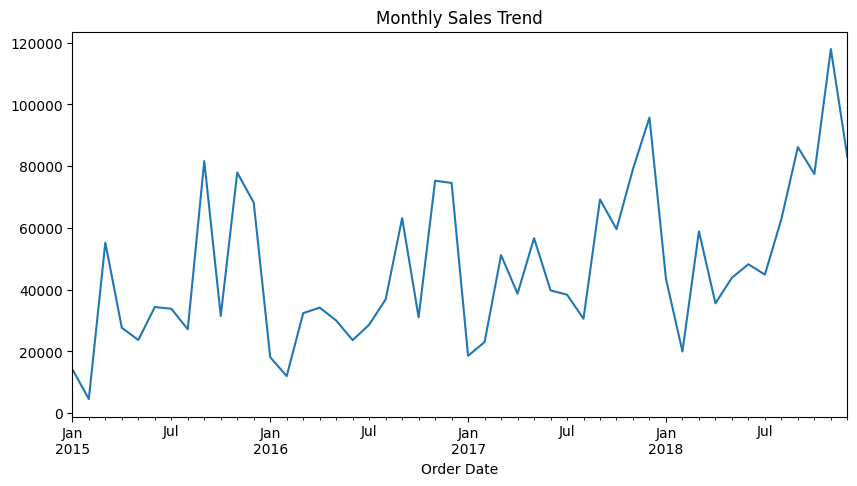

In [8]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', figsize=(10,5), title='Monthly Sales Trend')
plt.show()

The monthly sales trend visualization reveals clear seasonality in sales, with peaks typically observed towards the end of each year (e.g., late 2015, late 2016, late 2017, late 2018), possibly corresponding to holiday shopping seasons. Sales generally dip at the beginning of the year. There's also an overall upward trend in sales volume over the four-year period, indicating business growth. The most recent peak in late 2018 shows the highest monthly sales recorded, suggesting strong end-of-year performance. This pattern is vital for inventory management, marketing campaign timing, and forecasting future sales.